In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


# TASK 1: DATASET UNDERSTANDING

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("customer_support_text_classification.csv")

# Display first 5 rows
print("First 5 Rows:\n")
print(df.head())

# Display column names
print("\nColumns:")
print(df.columns)

# Automatically detect columns
text_col = df.columns[0]
label_col = df.columns[1]

print("\nText Column:", text_col)
print("Label Column:", label_col)

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Class distribution
print("\nClass Distribution:")
print(df[label_col].value_counts())

# Average text length
df['text_length'] = df[text_col].astype(str).apply(
    lambda x: len(x.split())
)

print("\nAverage Text Length:")
print(df['text_length'].mean())

# Sample texts
print("\nSample Text Records:")
print(df[text_col].head())

First 5 Rows:

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Text Column: ticket_id
Label Column: channel

Dataset Shape:
(1500, 6)

Class Distribution:
channel
email     326
social    314
ph

# TASK 2: Text Preprocessig

In [3]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')

# Load stopwords
stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Apply preprocessing
df['clean_text'] = df[text_col].astype(str).apply(clean_text)

# Display cleaned text
print(df[['clean_text']].head())

  clean_text
0        tkt
1        tkt
2        tkt
3        tkt
4        tkt


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hrishi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# TASK 3: Text Vectorization

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

# Target variable
y = df[label_col]

print("TF-IDF Shape:")
print(X.shape)

TF-IDF Shape:
(1500, 1)


# TASK 4: Baseline Model

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:")
print(accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.20333333333333334

Classification Report:
              precision    recall  f1-score   support

         app       0.00      0.00      0.00        58
        chat       0.00      0.00      0.00        63
       email       0.20      1.00      0.34        61
       phone       0.00      0.00      0.00        67
      social       0.00      0.00      0.00        51

    accuracy                           0.20       300
   macro avg       0.04      0.20      0.07       300
weighted avg       0.04      0.20      0.07       300



C:\Users\Hrishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hrishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hrishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# TASK 5: Results Section

C:\Users\Hrishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Model Evaluation:
      Metric     Value
0   Accuracy  0.203333
1  Precision  0.041344
2     Recall  0.203333
3   F1-Score  0.068717


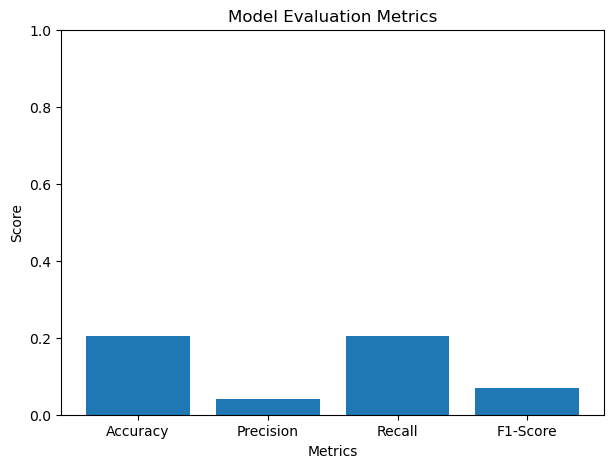


Sample Predictions:
   Actual Predicted
0   email     email
1    chat     email
2  social     email
3   phone     email
4    chat     email
5   phone     email
6   email     email
7   phone     email
8    chat     email
9     app     email


In [6]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Create results folder
os.makedirs("results", exist_ok=True)

# Calculate metrics
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

# Create evaluation dataframe
evaluation_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    'Value': [
        accuracy,
        precision,
        recall,
        f1
    ]
})

# Save evaluation CSV
evaluation_df.to_csv(
    "results/model_evaluation.csv",
    index=False
)

print("\nModel Evaluation:")
print(evaluation_df)

# ------------------------------------------
# SAVE MODEL EVALUATION PNG
# ------------------------------------------

plt.figure(figsize=(7,5))

plt.bar(
    evaluation_df['Metric'],
    evaluation_df['Value']
)

plt.ylim(0,1)

plt.title("Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")

# Save PNG
plt.savefig(
    "results/model_evaluation.png"
)

plt.show()

# ------------------------------------------
# SAVE SAMPLE PREDICTIONS TXT
# ------------------------------------------

sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

with open(
    "results/sample_predictions.txt",
    "w"
) as file:

    file.write("Sample Predictions\n")
    file.write("========================\n\n")

    for i in range(len(sample_df)):

        file.write(
            f"Actual: {sample_df.iloc[i]['Actual']} "
            f"| Predicted: {sample_df.iloc[i]['Predicted']}\n"
        )

print("\nSample Predictions:")
print(sample_df)

In [7]:
# TASK 6 — THEORY ANSWERS (Human Written)
# Why RNN struggles with long-term dependencies?
# RNN processes text word by word, but during long sequences it becomes difficult to retain information from earlier words. This happens because of the vanishing gradient problem, where important information gradually becomes weaker during training. As a result, standard RNNs often fail to capture long-term context in large sentences or documents.
# How LSTM improves memory handling?
# LSTM is designed to solve the memory limitation of traditional RNNs. It uses special gates such as forget gate, input gate, and output gate to control the flow of information. These gates help the model remember useful information for longer durations and forget unnecessary details. Because of this, LSTMs perform much better on sequence-based NLP tasks.
# What problem does Attention solve?
# Attention helps the model focus on the most important words in a sentence instead of treating all words equally. In long sequences, some words carry more meaning than others. Attention mechanisms allow the model to assign higher importance to relevant words, improving performance in tasks like translation, summarization, and question answering.
# Why are Transformers important in modern NLP?
# Transformers are important because they process entire sequences in parallel instead of word by word. They rely heavily on self-attention mechanisms, which help capture relationships between words efficiently. Transformers are faster to train, handle long text better, and form the foundation of modern AI systems such as GPT, BERT, and many Generative AI applications.